# Parameterizing hole Free-Volume theory for various polymers
# Application to the prediction of diffusivity of toluene

> Toluene is the most common surrogate for testing recyling plastics for food contact

This script shows the prediction of diffusivities of toluene using hole Free-Volume theory
at different temperatures in different polymers (LDPE, PMMA, PS, PVAc, PET).
gPET corresponds to dry PET (unplasticized) and wPET corresponds to plasticized PET.

Data have been extracted from the script figure8_revSep2019_2025.m used to generate
Figure 9 for the reference mentioned below.

REFERENCE
Zhu Y., Welle, F. and Vitrac O. A blob model to parameterize polymer hole free volumes and solute diffusion",
*Soft Matter* **2019**, 15(42), 8912-8932. DOI: https://doi.org/10.1039/C9SM01556F

ABSTRACT
*Solute diffusion in solid polymers has extensive applications in packaging, reservoir engineering, and biomedical technologies but remains poorly understood. The diffusion of non-entangled linear solutes with chemically identical patterns (blobs) deviates significantly in solid-state polymers, where the scaling exponent $\alpha_{\text{lin}} > 1$ (*Macromolecules*, 2013, *46*, 874), compared to their behavior in the molten state, where $\alpha_{\text{lin}} = 1$ (*Macromolecules*, 2007, *40*, 3970). This study leverages the scale invariance of diffusivities, $D$, for linear probes of the form*  

$$
D(N \cdot M_{\text{blob}} + M_{\text{anchor}},T,T_g) = N^{-\alpha_{\text{lin}}(T,T_g)} \cdot D(M_{\text{blob}} + M_{\text{anchor}},T,T_g)
$$

*where $N$ represents the number of identical blobs, each with mass $M_{\text{blob}}$, and possibly a distinct terminal pattern (anchor) of mass $M_{\text{anchor}}$. This formulation is used to evaluate the hole-free volume in seven polymers (aliphatic, semi-aromatic, and aromatic) across a broad temperature range, $-70\,\text{K} \leq T - T_g \leq 160\,\text{K}$. The new parameterization of hole-free volumes extends the applicability of the free-volume theory (FVT) developed by Vrentas and Duda to virtually any polymer, independent of the availability of pre-determined free-volume parameters. The predictive accuracy of this approach was validated using various solutes, including *n*-alkanes, 1-alcohols, *n*-alkyl acetates, and *n*-alkylbenzenes. The enthalpic and entropic contributions of both the blobs and the anchor were analyzed and quantified. A blind validation of the reformulated FVT demonstrated successful first-principles predictions of water and toluene diffusivities in amorphous polyethylene terephthalate over the temperature range $4^\circ\text{C}$ to $180^\circ\text{C}$, as well as in various other polymers. This new blob-based model enables the rational design of additives with controlled diffusivities in thermoplastics.*

## Dependencies

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## Constants

In [5]:
R = 8.31
T0K = 273.15  # K

## Polymer data ($T_g$ in K) stored in a dictionary.

In [7]:
data = {
    'LDPE': {'Tg': 148.15, 'D0': 1.87e-08, 'xi': 0.615,  'ref': 3, 'Ka': 144, 'Kb': 40, 'E': 0, 'r': 0.5},
    'PMMA': {'Tg': 381.15, 'D0': 1.87e-08, 'xi': 0.56,   'ref': 2, 'Ka': 252, 'Kb': 65, 'E': 0, 'r': 0.5},
    'PS':   {'Tg': 373.15, 'D0': 4.8e-08,  'xi': 0.584,  'ref': 2, 'Ka': 144, 'Kb': 40, 'E': 0, 'r': 0.5},
    'PVAc': {'Tg': 305.15, 'D0': 1.87e-08, 'xi': 0.86,   'ref': 4, 'Ka': 142, 'Kb': 40, 'E': 0, 'r': 0.5},
    'gPET': {'Tg': 349.15, 'D0': 1.0205e-08, 'xi': 0.6761, 'ref': 5, 'Ka': 252, 'Kb': 65, 'E': 0, 'r': 0.6153},
    'wPET': {'Tg': 316.15, 'D0': 1.02046e-08, 'xi': 0.6761, 'ref': 5, 'Ka': 252, 'Kb': 65, 'E': 0, 'r': 0.277734},
}

# References list (for documentation)
references = [
    'Vrentas and Vrentas, 1994',
    'Zielinski and Duda, 1992',
    'Lutzow et al., 1999',
    'Hong, 1995',
    # toluene in PET
    'Welle,2008',
    'Pennarun et al., 2004',
    'Welle,2013',
    'our work (permeation)',
    'our work (sorption)',
]

## Main function that computes the predicted diffusivity `DscalingPlike`

> `Plike` is a mathematical function representing polymer effects and strongly related to WLF model

In [9]:
def DscalingPlike(T, polymer):
    """
    Compute the predicted diffusivity using the scaling law.

    Parameters:
        T : float
            Temperature in Kelvin.
        polymer : str
            Polymer name (must be one of the keys in the data dictionary).

    Returns:
        float: Predicted diffusivity.
    """
    # Helper function to lookup a property value from the data dictionary.
    def lookup(P, prop):
        return data[P][prop]

    # Define alpha for T >= Tg.
    def alpha(T, Tg, Ka, Kb):
        return 1 + Ka / (T - Tg + Kb)

    # Define alphag for T < Tg.
    def alphag(T, Tg, Ka, Kb, r):
        return 1 + Ka / (r * (T - Tg) + Kb)

    deltaT = 2  # (K) sharpness of the transition at Tg

    # Heaviside-like function using tanh.
    def H(T_val, Tg_val):
        return 0.5 * (1 + np.tanh(4 / deltaT * (T_val - Tg_val)))

    # Composite alpha function that smoothly transitions between alpha and alphag.
    def alphaT(T, Tg, Ka, Kb, r):
        # Note: H(lookup(polymer, 'Tg'), T) computes H(Tg,T) and H(T, lookup(polymer, 'Tg')) computes H(T,Tg)
        return H(lookup(polymer, 'Tg'), T) * alphag(T, Tg, Ka, Kb, r) + H(T, lookup(polymer, 'Tg')) * alpha(T, Tg, Ka, Kb)

    betalin = 1
    # Function to compute Plike (see publication, Plike holds polymer effects)
    def Plike(T, polymer):
        Tg = lookup(polymer, 'Tg')
        Ka = lookup(polymer, 'Ka')
        Kb = lookup(polymer, 'Kb')
        r = lookup(polymer, 'r')
        return (alphaT(T, Tg, Ka, Kb, r) + betalin) / 0.24

    # Compute the predicted diffusivity.
    D0 = lookup(polymer, 'D0')
    E = lookup(polymer, 'E')
    xi = lookup(polymer, 'xi')

    return D0 * np.exp(-E / (R * T)) * np.exp(-xi * Plike(T, polymer))

## Test data (similar to a DataFrame) stored as a list of dictionaries.

In [11]:
test_data = [
    {'polymer': 'PS',    'T': 451.15, 'Dexp': 4e-11},
    {'polymer': 'PS',    'T': 433.15, 'Dexp': 1.5e-11},
    {'polymer': 'PS',    'T': 413.15, 'Dexp': 2e-12},
    {'polymer': 'PS',    'T': 383.15, 'Dexp': 1.5e-13},
    {'polymer': 'PMMA',  'T': 433.15, 'Dexp': 9e-13},
    {'polymer': 'PMMA',  'T': 413.15, 'Dexp': 2e-13},
    {'polymer': 'PMMA',  'T': 403.15, 'Dexp': 8e-14},
    {'polymer': 'LDPE',  'T': 343.15, 'Dexp': 7e-11},
    {'polymer': 'PVAc',  'T': 383.15, 'Dexp': 2e-12},
    {'polymer': 'PVAc',  'T': 353.15, 'Dexp': 1e-13},
    {'polymer': 'PVAc',  'T': 313.15, 'Dexp': 8e-16},
    {'polymer': 'PS',    'T': 388.15, 'Dexp': 7.2e-13},
    {'polymer': 'PS',    'T': 451.15, 'Dexp': 4e-11},
    {'polymer': 'PS',    'T': 433.15, 'Dexp': 1.5e-11},
    {'polymer': 'PS',    'T': 413.15, 'Dexp': 2e-12},
    {'polymer': 'PS',    'T': 383.15, 'Dexp': 1.5e-13},
    {'polymer': 'PS',    'T': 388.15, 'Dexp': 7.2e-13},
    {'polymer': 'PMMA',  'T': 433.15, 'Dexp': 9e-13},
    {'polymer': 'PMMA',  'T': 413.15, 'Dexp': 2e-13},
    {'polymer': 'PMMA',  'T': 403.15, 'Dexp': 8e-14},
    {'polymer': 'wPET',  'T': 313.15, 'Dexp': 4.1e-16},
    {'polymer': 'gPET',  'T': 313.15, 'Dexp': 2e-18},
    {'polymer': 'gPET',  'T': 313.15, 'Dexp': 3.8e-18},
    {'polymer': 'gPET',  'T': 333.15, 'Dexp': 2.6e-17},
    {'polymer': 'wPET',  'T': 313.15, 'Dexp': 6.3e-17},
    {'polymer': 'wPET',  'T': 313.15, 'Dexp': 2.1e-16},
    {'polymer': 'wPET',  'T': 313.15, 'Dexp': 4.8e-16},
    {'polymer': 'wPET',  'T': 323.15, 'Dexp': 4.1e-16},
    {'polymer': 'wPET',  'T': 323.15, 'Dexp': 6.1e-16},
    {'polymer': 'gPET',  'T': 373.15, 'Dexp': 3.26e-15},
    {'polymer': 'gPET',  'T': 453.15, 'Dexp': 2.78e-12},
    {'polymer': 'gPET',  'T': 434.15, 'Dexp': 1.17e-12},
    {'polymer': 'gPET',  'T': 414.15, 'Dexp': 1.9e-13},
    {'polymer': 'gPET',  'T': 394.15, 'Dexp': 2.47e-14},
]

## Compute predicted diffusivity for each test data point.

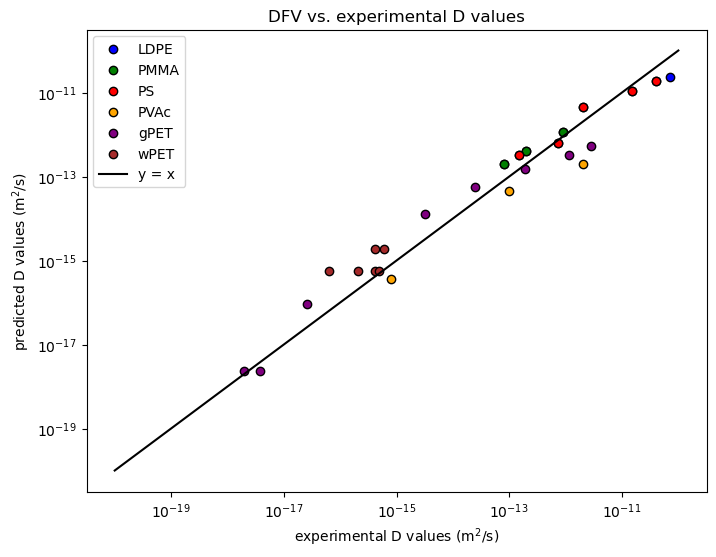

In [13]:
for entry in test_data:
    entry['Dpred'] = DscalingPlike(entry['T'], entry['polymer'])

# Plot experimental vs predicted D values.

plt.figure(figsize=(8, 6))

# Define a color map for polymers.
colors = {
    'LDPE': 'blue',
    'PMMA': 'green',
    'PS': 'red',
    'PVAc': 'orange',
    'gPET': 'purple',
    'wPET': 'brown'
}

# Plot points for each polymer with its own color.
for polymer in colors.keys():
    x = [entry['Dexp'] for entry in test_data if entry['polymer'] == polymer]
    y = [entry['Dpred'] for entry in test_data if entry['polymer'] == polymer]
    if x:  # Only plot if there are data points.
        plt.scatter(x, y, label=polymer, color=colors[polymer], edgecolors='k')

# Plot the reference line y = x.
x_vals = np.logspace(-20, -10, 100)
plt.plot(x_vals, x_vals, 'k-', label='y = x')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('experimental D values (m$^2$/s)')
plt.ylabel('predicted D values (m$^2$/s)')
plt.title('DFV vs. experimental D values')
plt.legend()
plt.show()